# Bölüm 5c — Brickset'ten Toplu Retail Price Çekimi

**Amaç:** Faz 5c kapsamında, BrickEconomy'ye ek/tamamlayıcı bir kaynak olarak
[Brickset](https://brickset.com) API v3'ünden (`getSets`) tüm analiz-hazır
setler için retail price verisini **toplu** şekilde çekmek. BrickEconomy'nin
aksine Brickset ücretsiz ve günlük kota (100 `getSets` çağrısı) çok daha
yüksek olduğu için, tüm setleri **yıl bazlı sorgularla tek oturumda**
çekebiliyoruz.

**Strateji (önceki keşif adımında netleştirildi):**
- Kimlik doğrulama: `apiKey` + boş `userHash` (public set verisi için hash
  gerekmiyor)
- Sorgu birimi: yıl (`sets_clean.csv`'deki 75 farklı yıl, 1949–2025)
- Sayfalama: `pageSize=2000` + `matches` kontrolü (taşarsa `pageNumber` ile
  devam)
- Rate limit: istekler arası ~15 saniye bekleme (dakikada 4 istek)
- Günlük kota güvenliği: her yıldan önce `getKeyUsageStats` ile kontrol,
  90/100'e ulaşılırsa **dur**, kalan yılları ertesi güne bırak
- Kesintiye dayanıklılık (resumable): her yılın ham sonucu
  `data/raw/brickset/{year}.json` olarak kaydedilir; dosya zaten varsa o yıl
  tekrar çekilmez

Yardımcı fonksiyonlar [`src/brickset_api.py`](../src/brickset_api.py) içinde.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv(PROJECT_ROOT / ".env")
api_key = os.environ.get("BRICKSET_API_KEY")
assert api_key, "BRICKSET_API_KEY .env içinde bulunamadı"

from brickset_api import fetch_all_years, extract_price_row

RAW_DIR = PROJECT_ROOT / "data/raw/brickset"
PROCESSED_DIR = PROJECT_ROOT / "data/processed"
print("Proje kökü:", PROJECT_ROOT)

Proje kökü: /Users/didemarslan/Downloads/brick_by_brick_data


## 1) Çekilecek yılları belirle

In [2]:
sets_clean = pd.read_csv(PROCESSED_DIR / "sets_clean.csv")
ready = sets_clean[sets_clean["is_analysis_ready"] == True]
years = sorted(int(y) for y in ready["year"].unique())

print(f"is_analysis_ready==True set sayısı: {len(ready)}")
print(f"Farklı yıl sayısı: {len(years)} ({years[0]}-{years[-1]})")
print("En yoğun 5 yıl:")
print(ready["year"].value_counts().sort_values(ascending=False).head(5))

is_analysis_ready==True set sayısı: 18190
Farklı yıl sayısı: 75 (1949-2025)
En yoğun 5 yıl:
year
2025    855
2024    777
2021    721
2023    710
2022    684
Name: count, dtype: int64


## 2) Toplu çekim (resumable)

Bu hücre her yıl için `data/raw/brickset/{year}.json` dosyasını kontrol eder;
varsa atlar, yoksa günlük kota kontrolüyle birlikte çeker. Not defteri daha
önce çalıştırılmışsa (ör. arka planda script ile), bu hücrenin çalıştırılması
sadece eksik yılları tamamlar — API çağrısı yapmadan hızlıca biter.

In [3]:
result = fetch_all_years(api_key, years, RAW_DIR)
print()
print("=== Özet ===")
print(f"Bu çalıştırmada yeni çekilen yıl sayısı: {len(result['fetched'])}")
print(f"Zaten önbellekte olup atlanan yıl sayısı: {len(result['skipped_cached'])}")
print(f"Durdurulan yıl (varsa): {result['stopped_at']}")
print(f"Son bilinen günlük kullanım: {result['last_known_usage']}")

cached_years = sorted(int(p.stem) for p in RAW_DIR.glob("*.json"))
missing_years = sorted(set(years) - set(cached_years))
print(f"\nToplam önbellekte bulunan yıl dosyası: {len(cached_years)}/{len(years)}")
if missing_years:
    print(f"Eksik kalan yıllar (ertesi gün devam edilecek): {missing_years}")
else:
    print("Tüm yıllar başarıyla çekildi.")


=== Özet ===
Bu çalıştırmada yeni çekilen yıl sayısı: 0
Zaten önbellekte olup atlanan yıl sayısı: 75
Durdurulan yıl (varsa): None
Son bilinen günlük kullanım: None

Toplam önbellekte bulunan yıl dosyası: 75/75
Tüm yıllar başarıyla çekildi.


## 3) JSON'ları birleştir → `brickset_prices.csv`

In [4]:
import json

rows = []
for path in sorted(RAW_DIR.glob("*.json")):
    year_data = json.loads(path.read_text())
    for set_obj in year_data.get("sets", []):
        rows.append(extract_price_row(set_obj))

brickset_prices = pd.DataFrame(rows)
before = len(brickset_prices)
brickset_prices = brickset_prices.dropna(subset=["brickset_set_num"])
brickset_prices = brickset_prices.drop_duplicates(subset=["brickset_set_num"], keep="first")
after = len(brickset_prices)
print(f"Ham satır: {before}, brickset_set_num'suz/tekrarlı düşülen: {before - after}, final: {after}")

out_path = PROCESSED_DIR / "brickset_prices.csv"
brickset_prices.to_csv(out_path, index=False)
print(f"Kaydedildi: {out_path}")
brickset_prices.head()

Ham satır: 22311, brickset_set_num'suz/tekrarlı düşülen: 0, final: 22311
Kaydedildi: /Users/didemarslan/Downloads/brick_by_brick_data/data/processed/brickset_prices.csv


,brickset_set_num,retail_price_us,retail_price_uk,retail_price_ca,retail_price_de,date_first_available,date_last_available
0,700-12,NaN,NaN,NaN,NaN,NaN,NaN
1,700_1_1-1,NaN,NaN,NaN,NaN,NaN,NaN
2,700_1_2-1,NaN,NaN,NaN,NaN,NaN,NaN
3,700_A-1,NaN,NaN,NaN,NaN,NaN,NaN
4,700_B_1-1,NaN,NaN,NaN,NaN,NaN,NaN


## 4) `sets_clean.csv` ile LEFT JOIN testi (kalıcı değil — sadece eşleşme oranını ölçmek için)

`sets_clean.csv`'deki `set_num` ile `brickset_prices.csv`'deki
`brickset_set_num` üzerinden test amaçlı bir LEFT JOIN. **Bu birleştirme
`sets_clean.csv`'ye kalıcı olarak yazılmıyor** — sadece Bölüm 2 (fiyat
tahmini regresyonu) için gerçekte kaç setin retail price verisiyle
kullanılabilir olacağını görmek içindir.

In [5]:
test_merge = sets_clean.merge(
    brickset_prices, left_on="set_num", right_on="brickset_set_num", how="left"
)

total = len(test_merge)
matched = test_merge["retail_price_us"].notna().sum()
unmatched = total - matched

print(f"Toplam set (sets_clean.csv): {total}")
print(f"Retail price ile eşleşen: {matched} ({matched/total:.1%})")
print(f"Eşleşmeyen (retail price'sız kalan): {unmatched} ({unmatched/total:.1%})")

ready_total = len(sets_clean[sets_clean['is_analysis_ready'] == True])
ready_matched = test_merge[test_merge['is_analysis_ready'] == True]['retail_price_us'].notna().sum()
print()
print(f"Sadece is_analysis_ready==True içinde: {ready_matched}/{ready_total} ({ready_matched/ready_total:.1%}) eşleşti")
print("(Bölüm 2 regresyonu için gerçek kullanılabilir örneklem büyüklüğü budur.)")

Toplam set (sets_clean.csv): 18899
Retail price ile eşleşen: 6620 (35.0%)
Eşleşmeyen (retail price'sız kalan): 12279 (65.0%)

Sadece is_analysis_ready==True içinde: 6614/18190 (36.4%) eşleşti
(Bölüm 2 regresyonu için gerçek kullanılabilir örneklem büyüklüğü budur.)


## 5) Not: Brickset yıl toplamları neden bizimkinden yüksek çıkıyor?

Keşif adımında gördüğümüz gibi, Brickset'in bir yıl için döndürdüğü toplam
set sayısı (`matches`), `sets_clean.csv`'deki aynı yılın set sayısından
genelde daha yüksek (ör. 2020: Brickset 860 vs. bizim csv 678, ~%27 fark).

**Neden:** Brickset'in veritabanı sadece "normal" LEGO setlerini değil, aynı
zamanda bizim Faz 4'te (`sets_clean.csv` temizliğinde) zaten filtrelediğimiz
**merch/gear/promosyon kategorilerini** de (anahtarlıklar, kitaplar,
sadece-minifigür paketleri, "gear" ürünleri vb.) içeriyor.

**Bunun eşleştirmeyi etkilememesinin nedeni:** Yukarıdaki LEFT JOIN,
**`sets_clean.csv`'yi temel alıyor** (sol taraf) — yani sadece bizim zaten
sahip olduğumuz/filtrelediğimiz setler için Brickset'te bir eşleşme arıyoruz.
Brickset tarafındaki "fazladan" merch/gear satırları LEFT JOIN'de hiç
görünmüyor (sağ tarafta kalıp solda karşılığı olmadığı için otomatik
düşüyorlar). Dolayısıyla yıl toplamlarındaki bu fark, yukarıdaki eşleşme
oranını hiçbir şekilde bozmuyor — sadece Brickset'in daha geniş bir
kategori yelpazesini kapsadığını gösteriyor.

## 6) Eşleşme yanlılığı kontrolü

Bölüm 2 (fiyat tahmini regresyonu) için gerçekten kullanılabilir örneklem
sadece **retail price ile eşleşen 6.614 set**. Bu alt kümenin tüm popülasyonu
(18.190 analiz-hazır set) makul ölçüde temsil edip etmediğini üç açıdan
kontrol ediyoruz: yıl, tema, parça sayısı. Henüz modelleme yok — sadece
tanımlayıcı karşılaştırma.

In [6]:
import matplotlib.pyplot as plt

# Palet: kategorik slot 1 (mavi) = eşleşen, slot 2 (turuncu) = eşleşmeyen — sabit sıra
COLOR_MATCHED = "#2a78d6"
COLOR_UNMATCHED = "#eb6834"
INK = "#0b0b0b"
MUTED = "#898781"
GRID = "#e1e0d9"

ready_merge = test_merge[test_merge["is_analysis_ready"] == True].copy()
matched = ready_merge[ready_merge["retail_price_us"].notna()]
unmatched = ready_merge[ready_merge["retail_price_us"].isna()]
print(f"Eşleşen: {len(matched)}, Eşleşmeyen: {len(unmatched)} (toplam {len(ready_merge)})")

Eşleşen: 6614, Eşleşmeyen: 11576 (toplam 18190)


### 6.1) Yıl dağılımı

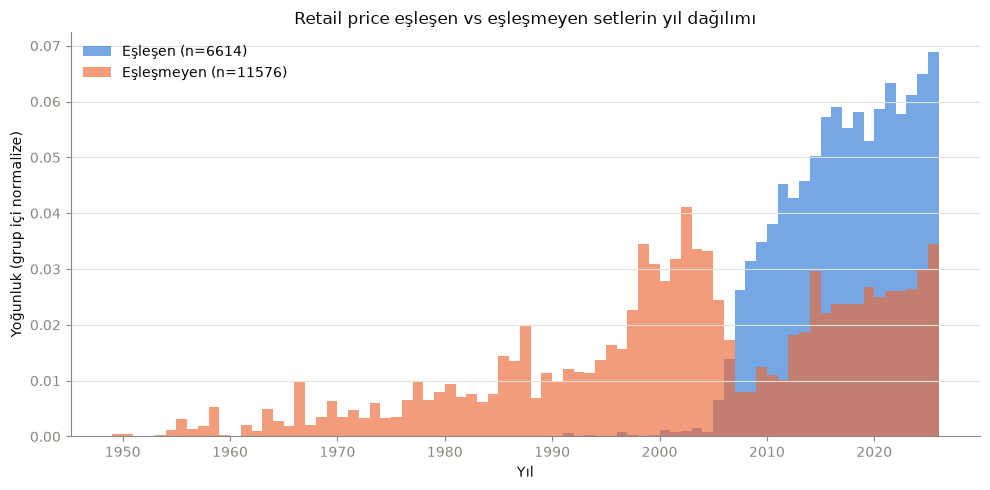

Eşleşen medyan/ortalama yıl: 2017 / 2016.8
Eşleşmeyen medyan/ortalama yıl: 2003 / 2002.3
Eşleşenlerin %65.7'i 2015+, eşleşmeyenlerin sadece %28.8'i 2015+
Eşleşenlerin %0.2'i 2000-öncesi, eşleşmeyenlerin %38.6'i 2000-öncesi


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
bins = range(1949, 2027)
ax.hist(matched["year"], bins=bins, density=True, alpha=0.65,
        color=COLOR_MATCHED, label=f"Eşleşen (n={len(matched)})")
ax.hist(unmatched["year"], bins=bins, density=True, alpha=0.65,
        color=COLOR_UNMATCHED, label=f"Eşleşmeyen (n={len(unmatched)})")
ax.set_xlabel("Yıl", color=INK)
ax.set_ylabel("Yoğunluk (grup içi normalize)", color=INK)
ax.set_title("Retail price eşleşen vs eşleşmeyen setlerin yıl dağılımı", color=INK)
ax.legend(frameon=False)
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
for s in ["left", "bottom"]:
    ax.spines[s].set_color(MUTED)
ax.tick_params(colors=MUTED)
plt.tight_layout()
plt.show()

print(f"Eşleşen medyan/ortalama yıl: {matched['year'].median():.0f} / {matched['year'].mean():.1f}")
print(f"Eşleşmeyen medyan/ortalama yıl: {unmatched['year'].median():.0f} / {unmatched['year'].mean():.1f}")
print(f"Eşleşenlerin %{(matched['year']>=2015).mean()*100:.1f}'i 2015+, eşleşmeyenlerin sadece %{(unmatched['year']>=2015).mean()*100:.1f}'i 2015+")
print(f"Eşleşenlerin %{(matched['year']<2000).mean()*100:.1f}'i 2000-öncesi, eşleşmeyenlerin %{(unmatched['year']<2000).mean()*100:.1f}'i 2000-öncesi")

### 6.2) Tema dağılımı — en sık 10 tema

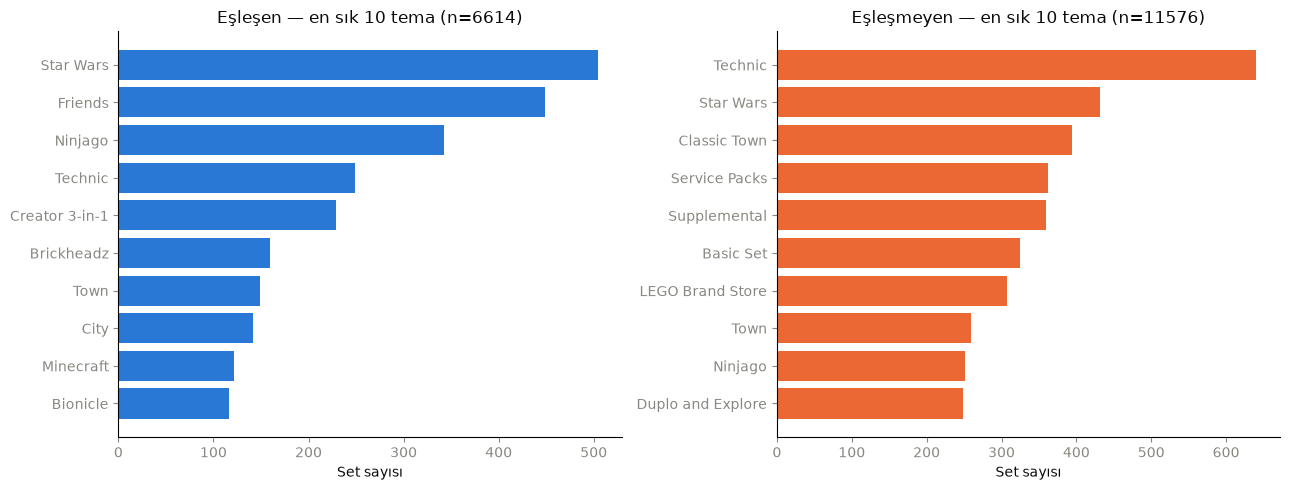

Her iki top-10'da da olan temalar (4): ['Ninjago', 'Star Wars', 'Technic', 'Town']
Sadece eşleşenlerin top-10'unda: ['Bionicle', 'Brickheadz', 'City', 'Creator 3-in-1', 'Friends', 'Minecraft']
Sadece eşleşmeyenlerin top-10'unda: ['Basic Set', 'Classic Town', 'Duplo and Explore', 'LEGO Brand Store', 'Service Packs', 'Supplemental']


In [8]:
top_matched_themes = matched["theme_name"].value_counts().head(10)
top_unmatched_themes = unmatched["theme_name"].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(top_matched_themes.index[::-1], top_matched_themes.values[::-1], color=COLOR_MATCHED)
axes[0].set_title(f"Eşleşen — en sık 10 tema (n={len(matched)})", color=INK)
axes[1].barh(top_unmatched_themes.index[::-1], top_unmatched_themes.values[::-1], color=COLOR_UNMATCHED)
axes[1].set_title(f"Eşleşmeyen — en sık 10 tema (n={len(unmatched)})", color=INK)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(colors=MUTED)
    ax.set_xlabel("Set sayısı", color=INK)
plt.tight_layout()
plt.show()

overlap = set(top_matched_themes.index) & set(top_unmatched_themes.index)
print(f"Her iki top-10'da da olan temalar ({len(overlap)}): {sorted(overlap)}")
print(f"Sadece eşleşenlerin top-10'unda: {sorted(set(top_matched_themes.index) - overlap)}")
print(f"Sadece eşleşmeyenlerin top-10'unda: {sorted(set(top_unmatched_themes.index) - overlap)}")

### 6.3) `num_parts` dağılımı

            eşleşen    eşleşmeyen
count   6614.000000  11576.000000
mean     445.391745    114.356427
std      711.648296    268.991788
min        1.000000      1.000000
25%       79.000000     12.000000
50%      224.000000     35.000000
75%      525.000000    100.000000
max    11695.000000  10001.000000


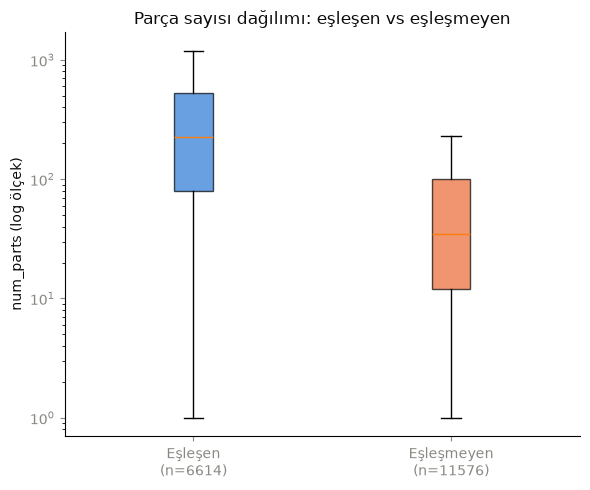

Medyan parça sayısı — eşleşen: 224, eşleşmeyen: 35 (~6.4x fark)
Ortalama parça sayısı — eşleşen: 445, eşleşmeyen: 114


In [9]:
summary = pd.DataFrame({
    "eşleşen": matched["num_parts"].describe(),
    "eşleşmeyen": unmatched["num_parts"].describe(),
})
print(summary)

fig, ax = plt.subplots(figsize=(6, 5))
bp = ax.boxplot(
    [matched["num_parts"].dropna(), unmatched["num_parts"].dropna()],
    tick_labels=[f"Eşleşen\n(n={len(matched)})", f"Eşleşmeyen\n(n={len(unmatched)})"],
    patch_artist=True, showfliers=False,
)
for patch, color in zip(bp["boxes"], [COLOR_MATCHED, COLOR_UNMATCHED]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_yscale("log")
ax.set_ylabel("num_parts (log ölçek)", color=INK)
ax.set_title("Parça sayısı dağılımı: eşleşen vs eşleşmeyen", color=INK)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(colors=MUTED)
plt.tight_layout()
plt.show()

ratio = matched["num_parts"].median() / unmatched["num_parts"].median()
print(f"Medyan parça sayısı — eşleşen: {matched['num_parts'].median():.0f}, eşleşmeyen: {unmatched['num_parts'].median():.0f} (~{ratio:.1f}x fark)")
print(f"Ortalama parça sayısı — eşleşen: {matched['num_parts'].mean():.0f}, eşleşmeyen: {unmatched['num_parts'].mean():.0f}")

### 6.4) Sonuç: eşleşen alt küme temsili mi, yoksa yanlı mı?

**Belirgin ve tutarlı bir yanlılık var — eşleşen alt küme tüm popülasyonu
makul ölçüde temsil ETMİYOR.** Üç kontrol de aynı yönde:

- **Yıl:** Eşleşenlerin medyan yılı **2017**, eşleşmeyenlerin **2003** — 14 yıl
  fark. Eşleşenlerin **%65.7'si 2015 sonrası**; eşleşmeyenlerde bu oran sadece
  **%28.8**. Neredeyse hiç eşleşen set 2000 öncesinden değil (%0.2), oysa
  eşleşmeyenlerin **%38.6'sı 2000 öncesi**. Yani eşleşen küme büyük ölçüde
  **modern (2015+) setlere yığılmış**.
- **Tema:** Eşleşenlerin top-10'u mainline/flagship temalarla dolu (Star Wars,
  Friends, Ninjago, Technic, Creator 3-in-1, Brickheadz, City, Minecraft...).
  Eşleşmeyenlerin top-10'unda ise **"Service Packs", "Supplemental", "Basic
  Set", "LEGO Brand Store", "Classic Town", "Duplo and Explore"** gibi
  küçük/yardımcı/eski kategoriler ağırlıkta. Star Wars, Technic, Town ve
  Ninjago her iki listede de var (bu temalar hem eski hem yeni çok sayıda set
  içeriyor), ama eşleşmeyenlerin listesi büyük ölçüde **ana ürün hattı
  dışındaki** kategorilerden oluşuyor.
- **Parça sayısı:** Eşleşenlerin medyan parça sayısı **224**, eşleşmeyenlerin
  **35** — yaklaşık **6.4x fark**. Ortalamada da benzer bir uçurum var (445 vs
  114). Yani **büyük/premium setler çok daha yüksek oranda eşleşiyor, küçük
  setler neredeyse hiç eşleşmiyor**.

**Neden böyle olduğu makul bir açıklaması var:** Brickset'in
`LEGOCom.US.retailPrice` alanı, LEGO'nun kendi online mağazasında (lego.com
Shop) satılan setler için doluyor. LEGO'nun online mağazası 2000'lerin
ortasından itibaren önem kazandı ve öncelikle ana ürün hattındaki (flagship)
setleri kapsıyor — küçük parça paketleri, servis parçaları, Classic
Town/Duplo gibi eski/yardımcı kategoriler genelde hiç lego.com'da tekil
ürün olarak satılmadı.

**Bölüm 2 raporunda dürüstçe belirtilmesi gereken limitasyon:** Fiyat tahmini
modeli eğitilecek 6.614 setlik örneklem **rastgele bir alt küme değil** —
**yeni (özellikle 2015 sonrası) ve büyük/flagship setlere yığılmış** bir
örneklem. Bu modelden çıkan sonuçlar (ör. "parça başına fiyat" katsayıları)
**eski ve küçük setlere genellenemez** — model büyük ölçüde "modern, büyük,
flagship set" popülasyonu üzerinde eğitilmiş olacak. Bu, modelleme aşamasında
regresyon sonuçlarını yorumlarken açıkça belirtilmesi gereken bir
seçim/örneklem yanlılığıdır (selection bias).